In [45]:
from dtwa_non_integrated import run_dtwa
import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt 

# Markovian Limit

In [46]:
p = {
    "n_spins": 50,
    "omega_0": 1.0,
    "B_z": 1.0,
    "alpha": 0.05,
    "omega_c": 5.0,
    "s": 1.0,
    "g": 0.10,
    "T": 0.01,
    "initial_direction": jnp.array([0.1, 0.0, 0.99]),
    "n_photons_initial": 0.0, 
    "time_steps": 5_000,
    "frequency_steps": 5_000, 
    "n_trajectories": 5_000,
    "batch_size": 5_000
}

key=jax.random.PRNGKey(42)
t_max = 200

_, subkey = jax.random.split(key)
dtwa_keys = jax.random.split(subkey, 10)

t_grid = jnp.linspace(0, t_max, p["time_steps"])
dt = t_grid[1]-t_grid[0]

B_field_pre = jnp.zeros((p["time_steps"], 3))
B_field_pre = B_field_pre.at[:, 0].set(1e-4) # Tip the scale
B_field_pre = B_field_pre.at[:, 2].set(p["B_z"])
j_val = p["n_spins"] / 2.0

In [47]:
def get_analytical_steady_state(g, omega_0, B_z, n_spins):
    """Calculates the exact mean-field steady state for the Dicke model."""
    # 1. Calculate the intensive z-spin
    j_z_ss = - (omega_0 * B_z) / (4.0 * g**2)
    
    if j_z_ss <= -1.0:
        # Normal Phase: The origin is the true stable ground state
        return 0.0j, jnp.array([0.0, 0.0, -1.0])
    else:
        # Superradiant Phase: Calculate the broken-symmetry well coordinates
        j_x_ss = jnp.sqrt(1.0 - j_z_ss**2)
        
        # Steady-state cavity displacement
        alpha_ss = - (g * jnp.sqrt(n_spins) / omega_0) * j_x_ss + 0.0j
        
        return alpha_ss, jnp.array([j_x_ss, 0.0, j_z_ss])

In [48]:
key=jax.random.PRNGKey(42)
t_max = 200

_, subkey = jax.random.split(key)
dtwa_keys = jax.random.split(subkey, p['n_trajectories'])

t_grid = jnp.linspace(0, t_max, p["time_steps"])
dt = t_grid[1]-t_grid[0]

B_field_pre = jnp.zeros((p["time_steps"], 3))
B_field_pre = B_field_pre.at[:, 0].set(1e-4) # Tip the scale
B_field_pre = B_field_pre.at[:, 2].set(p["B_z"])
j_val = p["n_spins"] / 2.0

alpha_ss, J_ss_norm = get_analytical_steady_state(p['g'], p["omega_0"], p["B_z"], p["n_spins"])

stats = run_dtwa(
    keys=dtwa_keys, 
    t_grid=t_grid, 
    omega_0=p["omega_0"], 
    alpha=p["alpha"],
    omega_c=p["omega_c"], 
    s=p['s'], 
    T=p["T"], 
    B_field=B_field_pre,
    g=p["g"], 
    n_photons_initial=alpha_ss,
    initial_direction=J_ss_norm, 
    batch_size=p['batch_size'],
    w_max=2*p['omega_c'],    
    N_w=p['frequency_steps'],      
    use_noise=True, 
    use_sampling=True
)

Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!


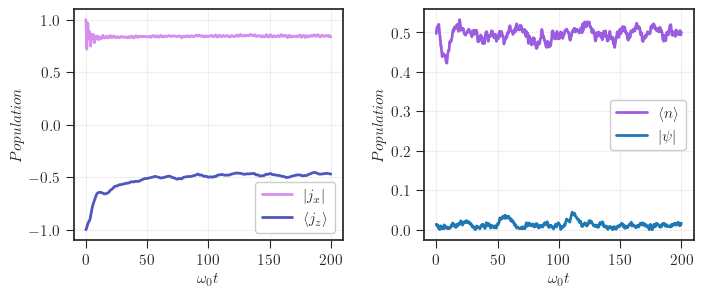

In [49]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(t_grid, stats['abs_jx'], linewidth = 2, label = r'$\vert j_x \vert$', 
           color = '#D78FEE')
ax[0].plot(t_grid, stats['j_z'], linewidth = 2, label = r'$\langle j_z \rangle$',
           color = '#4E56C0')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega_0 t$')
ax[0].set_ylabel(r'$Population$')
ax[0].legend()

ax[1].plot(t_grid, stats['mean_photon_number'], linewidth = 2, label = r'$\langle n \rangle$', 
           color = '#9B5DE0')
ax[1].plot(t_grid, stats['abs_mean_psi'], linewidth = 2, label = r'$\vert \psi \vert$')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega_0 t$')
ax[1].set_ylabel(r'$Population$')
ax[1].legend()

plt.savefig('dynamics.png', dpi = 300, bbox_inches='tight')
plt.show()